# Modelo Simple 6

En este modelo probamos a cambiar el tamaño de la segunda capa convolucional a tamaño 32. 

In [5]:
# El siguiente codigo sirve para que el notebook funcione igual en colab o en local
# Si se ejecuta en la nube se cargue el repositorio, de esta forma se pueda acceder 
# a los diferentes archivos que necesite para su ejecución de forma automatica
import sys
import os

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    repo_path = '/content/eye_diseases_classification_trabajo_DL'
    if not os.path.exists(repo_path):
        !git clone https://github.com/ropas5/eye_diseases_classification_trabajo_DL.git
        sys.path.append('/content/eye_diseases_classification_trabajo_DL/notebooks')
    # from google.colab import userdata
    # userdata.get('kaggle')
    else:
        print("Repo ya existe, actualizando")
        %cd /content/eye_diseases_classification_trabajo_DL/notebooks
        !git pull 
        
    #Cargamos el kaggle.json
    import ipywidgets as widgets
    from IPython.display import display
    
    uploader = widgets.FileUpload(accept='.json')
    display(uploader)
else:
    print("Ejecución en local")
    uploader = None

Repo ya existe, actualizando
/content/eye_diseases_classification_trabajo_DL/notebooks
remote: Enumerating objects: 9, done.
remote: Counting objects: 100% (9/9), done.
remote: Compressing objects: 100% (4/4), done.
remote: Total 6 (delta 2), reused 6 (delta 2), pack-reused 0 (from 0)
Unpacking objects: 100% (6/6), 225.47 KiB | 1.10 MiB/s, done.
From https://github.com/ropas5/eye_diseases_classification_trabajo_DL
   51b566a..2358404  main       -> origin/main
Updating 51b566a..2358404
Fast-forward
 models/simple_6_cnn.py          |   24 +
 notebooks/modelo_6_simple.ipynb | 1075 +++++++++++++++++++++++++++++++++++++++
 2 files changed, 1099 insertions(+)
 create mode 100644 models/simple_6_cnn.py
 create mode 100644 notebooks/modelo_6_simple.ipynb


FileUpload(value={}, accept='.json', description='Upload')

### Impotacion y preprocesado de datos

In [3]:
from importacion_preprocesado import descarga_y_carga_de_datos, preprocesamiento


tamany_img = (128,128) # tamaño reducido para colab, porque si no supera la ram
X, y = descarga_y_carga_de_datos(target_size=tamany_img, uploader = uploader)

X_train, X_val, X_test, y_train, y_val, y_test = preprocesamiento(X, y)

Dataset no encontrado, descargando y extrayendo...
Cargando imagenes
Dataset extraído en: data/raw/dataset
X shape: (4217, 128, 128, 3) y shape: (4217,)


### Modelo

In [6]:
# Importar el modelo
import sys
sys.path.append('../')

import importlib
import models.simple_6_cnn
importlib.reload(models.simple_6_cnn) # recargamos el cache para tener la ultima versión del modelo 
from models.simple_6_cnn import create_model

# Crear el modelo
model = create_model(input_shape=(128,128,3), num_classes=4, l_rate=0.01)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 124, 124, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 122, 122, 16)   │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 16)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │            68 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,108 (59.02 KB)

 Trainable params: 15,108 (59.02 KB)

 Non-trainable params: 0 (0.00 B)

### Entrenamiento

In [8]:
hist = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100
)

Epoch 1/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 290s 4s/step - accuracy: 0.3167 - loss: 1.3528 - val_accuracy: 0.3839 - val_loss: 1.2753
Epoch 2/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 276s 3s/step - accuracy: 0.4535 - loss: 1.1641 - val_accuracy: 0.4621 - val_loss: 1.1704
Epoch 3/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 272s 3s/step - accuracy: 0.4868 - loss: 1.0894 - val_accuracy: 0.4597 - val_loss: 1.1261
Epoch 4/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 330s 4s/step - accuracy: 0.4923 - loss: 1.0784 - val_accuracy: 0.4751 - val_loss: 1.0936
Epoch 5/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 267s 3s/step - accuracy: 0.4895 - loss: 1.0562 - val_accuracy: 0.4953 - val_loss: 1.0735
Epoch 6/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 269s 3s/step - accuracy: 0.4951 - loss: 1.0304 - val_accuracy: 0.4633 - val_loss: 1.0566
Epoch 7/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 349s 4s/step - accuracy: 0.5049 - loss: 1.0322 - val_accuracy: 0.5521 - val_loss: 1.0167
Epoch 8/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 223s 3s/step - accuracy: 0.5389 - loss: 0.9946 - val_accuracy: 0.

### Resultados

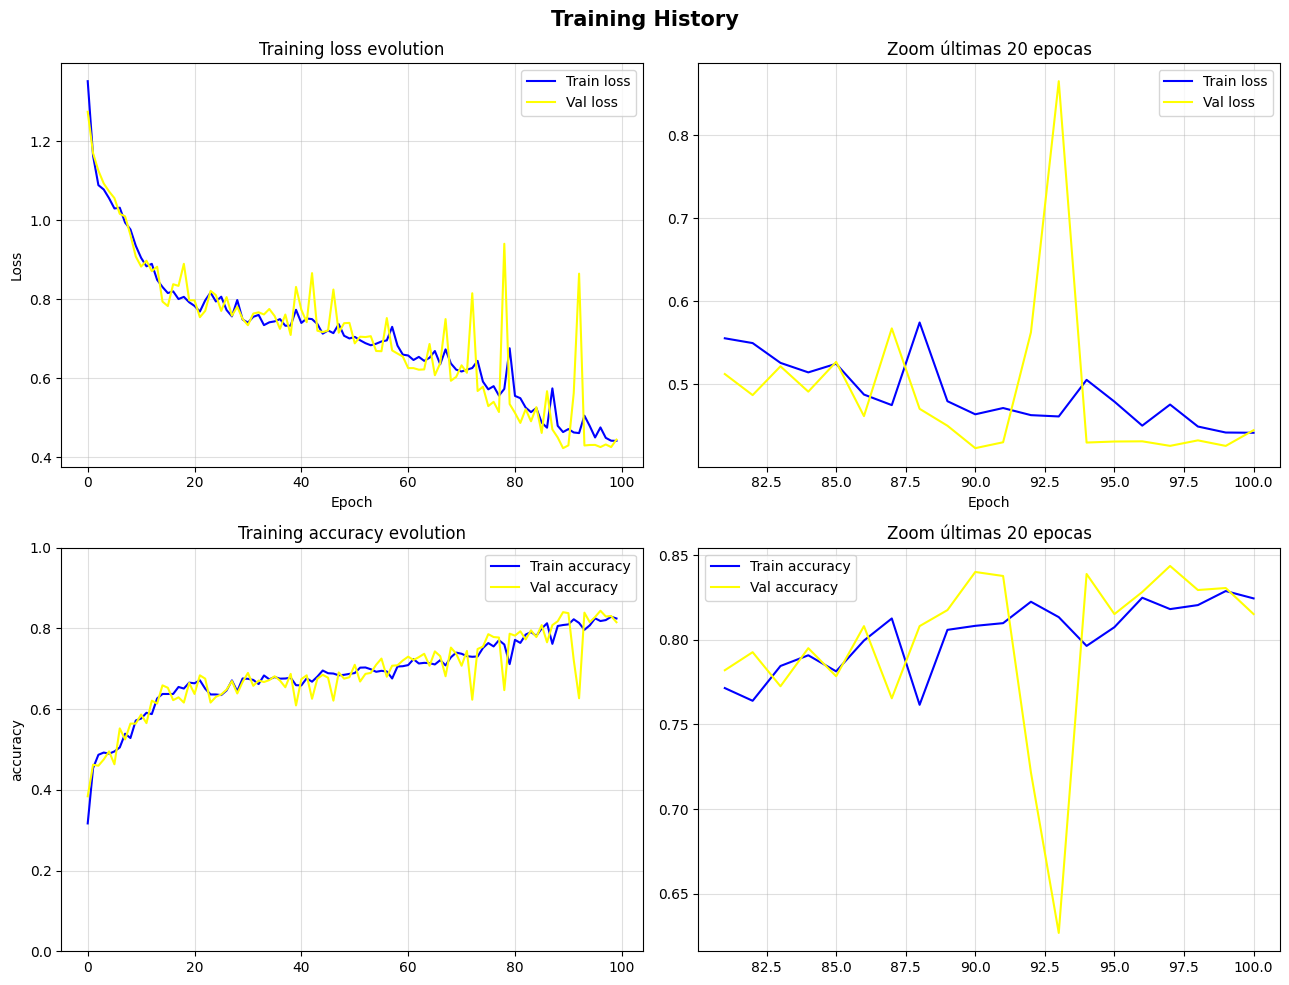

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# número de épocas para el zoom
zoom_epochs = 20

loss = hist.history['loss']
val_loss = hist.history['val_loss']
acc = hist.history["accuracy"]
val_acc = hist.history["val_accuracy"]

epochs = range(1, len(loss) + 1)

fig, ax = plt.subplots(2, 2, figsize=(13,10))
ax  = ax.flatten()
fig.suptitle('Training History', fontsize=15, fontweight='bold')

# Visualizacion evolucion loss durante el entrenamiento
ax[0].plot( loss, label='Train loss', color = "blue")
ax[0].plot( val_loss, label='Val loss', color= "yellow")
ax[0].set_title('Training loss evolution')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Loss')
ax[0].grid(True, alpha = 0.4)
ax[0].legend()

# Zoom últimas épocas
ax[1].plot(epochs[-zoom_epochs:], loss[-zoom_epochs:], label='Train loss', color = "blue")
ax[1].plot(epochs[-zoom_epochs:], val_loss[-zoom_epochs:], label='Val loss', color= "yellow")
ax[1].set_title(f'Zoom últimas {zoom_epochs} epocas')
ax[1].set_xlabel('Epoch')
ax[1].grid(True, alpha = 0.4)
ax[1].legend()

# Visualizacion de accuracy durante el entrenamiento
ax[2].plot( acc, label='Train accuracy', color = "blue")
ax[2].plot( val_acc, label='Val accuracy', color= "yellow")
ax[2].grid(True, alpha = 0.4)
ax[2].set_ylim(0,1)
ax[2].set_title('Training accuracy evolution')
ax[2].set_ylabel('accuracy')
ax[2].legend()

# Zoom últimas épocas
ax[3].plot(epochs[-zoom_epochs:], acc[-zoom_epochs:], label='Train accuracy', color = "blue")
ax[3].plot(epochs[-zoom_epochs:], val_acc[-zoom_epochs:], label='Val accuracy', color= "yellow")
ax[3].set_title(f'Zoom últimas {zoom_epochs} epocas')
ax[3].grid(True, alpha = 0.4)
ax[3].legend()

plt.tight_layout()
plt.show()

In [11]:
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, f1_score

datasets = {
    "Train": (X_train, y_train),
    "Val": (X_val, y_val),
    "Test": (X_test, y_test)
}

def evaluate(model, X, y):
    #Convertir a enteros
    y_true = np.argmax(y, axis=1)

    y_pred_probs = model.predict(X)
    y_pred = np.argmax(y_pred_probs, axis=1)

    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average="weighted")
    return acc, f1


def crear_df_metricas(model, datasets):
    results = {}
    for split_name, (X, y) in datasets.items():
        acc, f1 = evaluate(model, X, y)
        results[split_name] = [acc, f1]
    
    df = pd.DataFrame(results, index=["Accuracy", "F1"])
    return df

df = crear_df_metricas(model, datasets)


80/80 ━━━━━━━━━━━━━━━━━━━━ 73s 911ms/step
27/27 ━━━━━━━━━━━━━━━━━━━━ 22s 809ms/step
27/27 ━━━━━━━━━━━━━━━━━━━━ 21s 789ms/step


In [12]:
print(df.round(3))

          Train    Val   Test
Accuracy  0.811  0.815  0.808
F1        0.793  0.798  0.789


In [13]:
def plot_barra(metrica, titulo, color):

    plt.figure(figsize=(6,4))
    bars = plt.bar(metrica.index, metrica.values, color=color)
    plt.bar_label(bars)
    plt.title(f"{titulo}: Train vs Validation vs Test")
    plt.ylabel(titulo)
    plt.ylim(0,1)
    plt.grid(axis='y', linestyle='--')
    plt.show()


def plots_metricas(df):
    #Extraemos la fila
    accuracy = df.loc["Accuracy"]
    f1 = df.loc["F1"]

    #Grafico de Accuracy
    plot_barra(accuracy, titulo = "Accuracy", color="blue")

    #Grafico de 
    plot_barra(f1, titulo ="F1", color = "red")

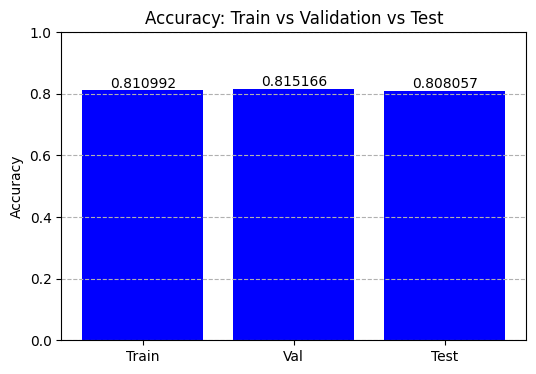

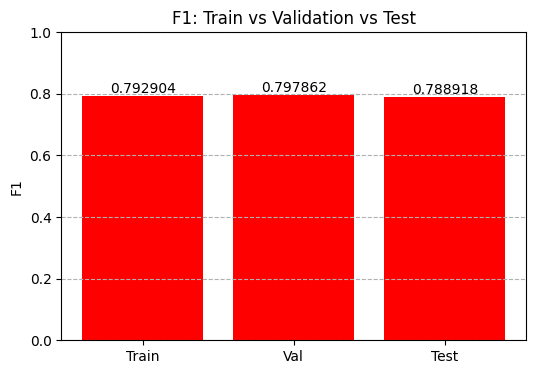

In [14]:
plots_metricas(df)

27/27 ━━━━━━━━━━━━━━━━━━━━ 22s 796ms/step


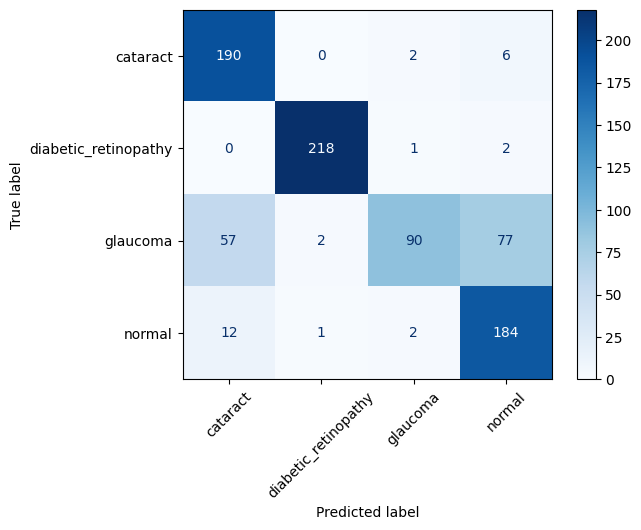

In [15]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_true = np.argmax(y_test, axis=1)
y_pred = np.argmax(model.predict(X_test), axis=1)

cm = confusion_matrix(y_true, y_pred)
ConfusionMatrixDisplay(cm,  
                    display_labels= ["cataract", "diabetic_retinopathy", "glaucoma", "normal"]
                    ).plot(cmap="Blues", xticks_rotation= 45.0)

In [16]:
from sklearn.metrics import precision_recall_fscore_support

def per_class_table(model, datasets):
    # class_names: lista con nombres de las clases en el orden de los índices (opcional)
    class_names = ["cataract", "diabetic_retinopathy", "glaucoma", "normal"]  

    splits = list(datasets.keys())
    # identificamos número de clases desde los datos si no dan nombres
    sample_X, sample_y = next(iter(datasets.values()))
    n_classes = np.argmax(sample_y, axis=1).max() + 1

    # DataFrame con index = clases y columnas por split/metric
    cols = []
    for s in splits:
        cols += [f"{s}_Accuracy", f"{s}_F1"]
    df = pd.DataFrame(index=class_names, columns=cols, dtype=float)

    for split in splits:
        X, y = datasets[split]
        y_true = np.argmax(y, axis=1)
        y_pred = np.argmax(model.predict(X), axis=1)

        # precision, recall, f1 por clase
        precision, recall, f1, support = precision_recall_fscore_support(
            y_true, y_pred, labels=np.arange(n_classes), zero_division=0
        )
        # Aquí definimos "Accuracy" por clase como recall (TP / nº verdaderos de la clase)
        for i, cls in enumerate(class_names):
            df.loc[cls, f"{split}_Accuracy"] = recall[i]
            df.loc[cls, f"{split}_F1"] = f1[i]

    return df

df_per_class = per_class_table(model, datasets)
df_per_class.round(3)

80/80 ━━━━━━━━━━━━━━━━━━━━ 63s 781ms/step
27/27 ━━━━━━━━━━━━━━━━━━━━ 22s 804ms/step
27/27 ━━━━━━━━━━━━━━━━━━━━ 22s 811ms/step


,Train_Accuracy,Train_F1,Val_Accuracy,Val_F1,Test_Accuracy,Test_F1
cataract,0.908,0.797,0.901,0.779,0.960,0.832
diabetic_retinopathy,0.981,0.987,0.991,0.991,0.986,0.986
glaucoma,0.381,0.520,0.388,0.528,0.398,0.561
normal,0.932,0.841,0.935,0.854,0.925,0.786


In [17]:

MODEL_NAME = "modelo_6_simple"          
EPOCHS     = len(hist.epoch)
results = {
    "modelo":         MODEL_NAME,
    "epochs":         EPOCHS,
    "Train Accuracy": df.loc["Accuracy", "Train"],
    "Val Accuracy":   df.loc["Accuracy", "Val"],
    "Test Accuracy":  df.loc["Accuracy", "Test"],
    "Train F1":       df.loc["F1", "Train"],
    "Val F1":         df.loc["F1", "Val"],
    "Test F1":        df.loc["F1", "Test"],

}

# Ruta del CSV
CSV_PATH = "../data/processed/model_results.csv"

if os.path.exists(CSV_PATH):
    df = pd.read_csv(CSV_PATH)
    df = pd.concat([df, pd.DataFrame([results])], ignore_index=True)
else:
    df = pd.DataFrame([results])

df.to_csv(CSV_PATH, index=False)

OSError: Cannot save file into a non-existent directory: '../data/processed'

In [ ]:
df